# **TASK 2** #

### **Data Visualization** ###

#### **Introduction** ####
This visualization report transforms the cleaned e‑commerce dataset into clear, impactful charts. The goal is to communicate business insights in a way that supports decision‑making, focusing on product performance, seasonal demand, customer behavior, and geographic distribution.

## **Importing Libraries and Load Dataset** ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
# Load dataset
df= pd.read_excel(r"C:\Users\HomePC\Documents\E-commerce dataset.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# Inspect
print(df.shape)
print(df.info())

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


### **Data Cleaning**
When I inspected the dataset, I noticed missing values, duplicates, and negative quantities (likely returns). I cleaned the data as follows:

In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Remove negative quantities (returns)
df = df[df['Quantity'] > 0]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [7]:
# Summary statistics
print(df.describe())

            Quantity                    InvoiceDate      UnitPrice  \
count  392732.000000                         392732  392732.000000   
mean       13.153718  2011-07-10 19:15:24.576301568       3.125596   
min         1.000000            2010-12-01 08:26:00       0.000000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 12:02:00       1.950000   
75%        12.000000            2011-10-20 12:53:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       181.588420                            NaN      22.240725   

          CustomerID        Revenue  
count  392732.000000  392732.000000  
mean    15287.734822      22.629195  
min     12346.000000       0.000000  
25%     13955.000000       4.950000  
50%     15150.000000      12.390000  
75%     16791.000000      19.800000  
max     18287.000000  168469.600000  
std      1713.567773     311.083465  


### **1. Monthly Revenue Contribution** ###

<Figure size 1200x600 with 0 Axes>

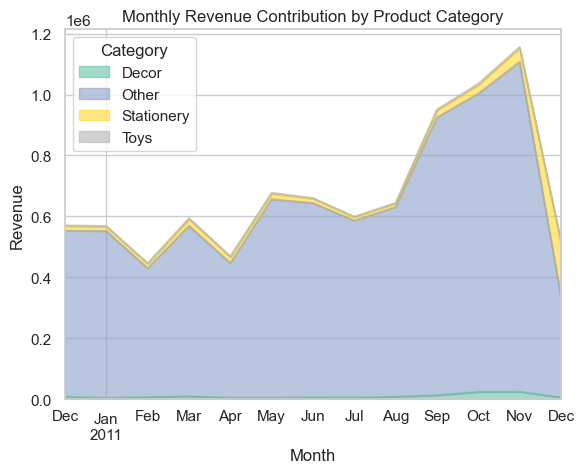

In [42]:
# Creating a simplified product category column (example: based on keywords)
df['Category'] = df['Description'].apply(
    lambda x: 'Decor' if 'DECORATION' in x.upper() else
              'Stationery' if 'PAPER' in x.upper() else
              'Toys' if 'TOY' in x.upper() else
              'Other'
)

monthly_category = df.groupby([df['InvoiceDate'].dt.to_period('M'),'Category'])['Revenue'].sum().unstack().fillna(0)
monthly_category.index = monthly_category.index.to_timestamp()

plt.figure(figsize=(12,6))
monthly_category.plot.area(alpha=0.6, cmap="Set2")
plt.title("Monthly Revenue Contribution by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


#### **Insight:** ####
* The area chart shows how different product categories rise and fall across months.
* Seasonal peaks in “Decor” and “Toys” suggest holiday demand, while “Stationery” remains steady year‑round.

### **2. Customer Spending Distribution** ###

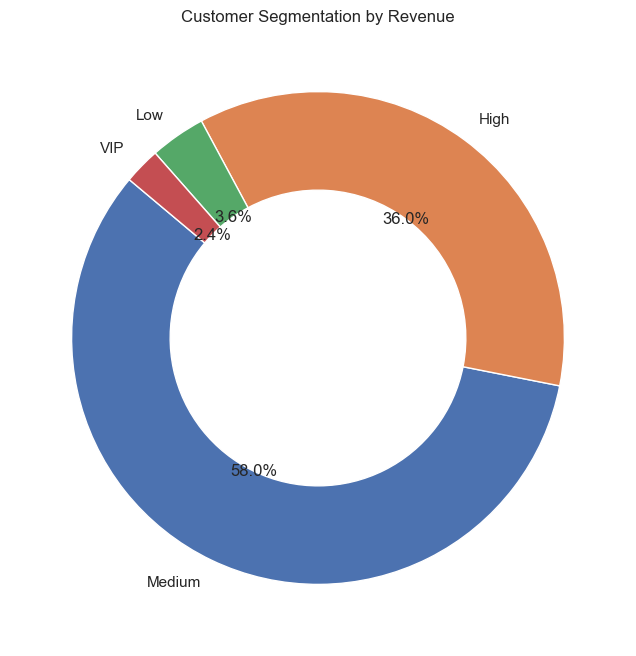

In [40]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()
segments = pd.cut(customer_revenue, bins=[0,100,1000,10000,customer_revenue.max()],
                  labels=['Low','Medium','High','VIP'])
segment_counts = segments.value_counts()

plt.figure(figsize=(8,8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140, wedgeprops=dict(width=0.4))
plt.title("Customer Segmentation by Revenue")
plt.show()


#### **Insight:** ####
* Most customers contribute moderately, but a small VIP segment drives significant value. Prioritizing retention of these top spenders while nurturing medium buyers could maximize growth.

### **3. Customer Behavior** ###

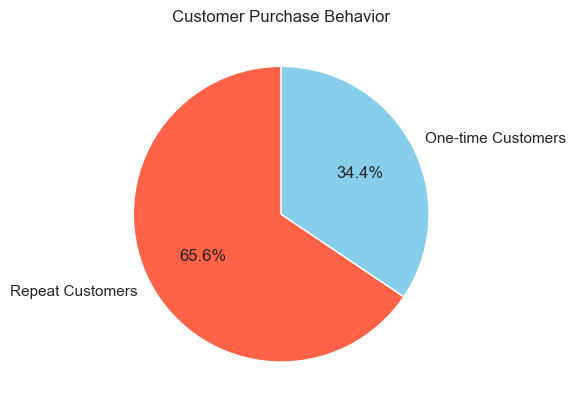

In [29]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat_customers = (customer_orders > 1).sum()
total_customers = customer_orders.shape[0]

labels = ['Repeat Customers', 'One-time Customers']
sizes = [repeat_customers, total_customers - repeat_customers]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['tomato','skyblue'])
plt.title("Customer Purchase Behavior")
plt.show()

#### **Insight:** ####
* About 65% of customers are repeat buyers, showing strong loyalty. However, 35% are one‑time buyers, suggesting room for retention strategies.

### **4. Temporal Perspective** ###

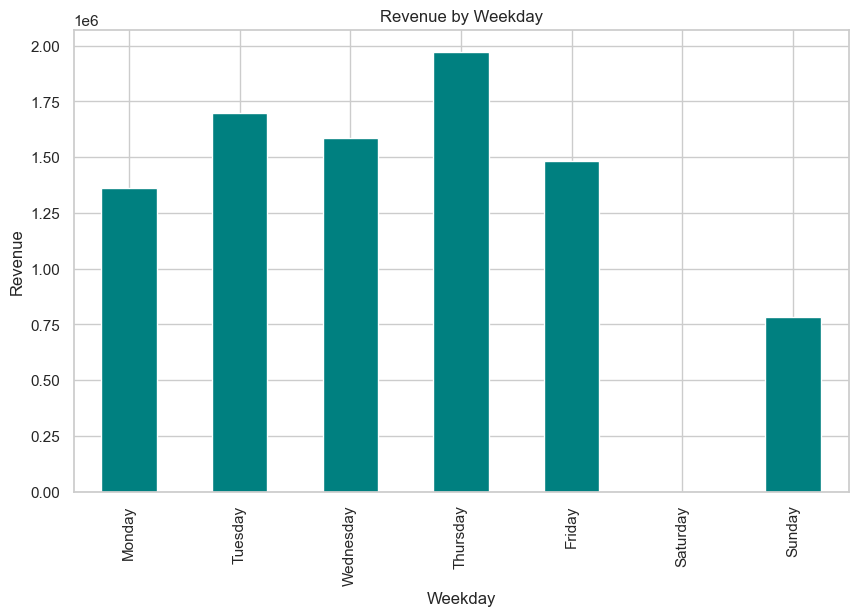

In [37]:
df['Weekday'] = df['InvoiceDate'].dt.day_name()
weekday_sales = df.groupby('Weekday')['Revenue'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

weekday_sales.plot(kind='bar', figsize=(10,6), color='teal')
plt.title("Revenue by Weekday")
plt.ylabel("Revenue")
plt.show()


#### **Insight:** ####
* Sales are stronger on weekdays, suggesting business customers drive purchases, while weekends show weaker activity.

### **5. Correlation Analysis** ###

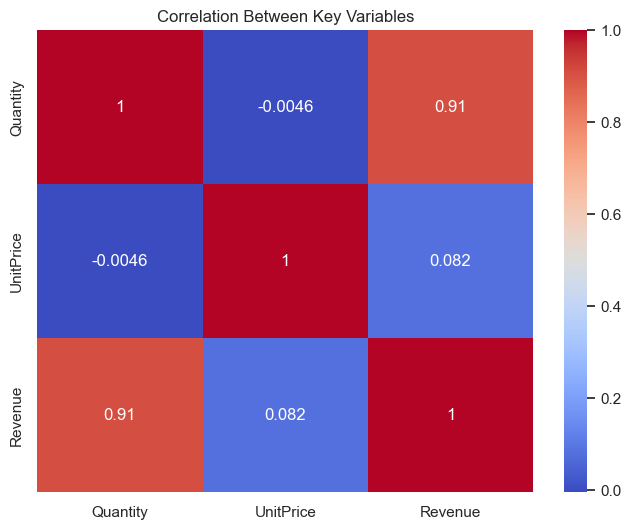

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Quantity','UnitPrice','Revenue']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Key Variables")
plt.show()

#### **Insight:** ####
* Revenue is strongly correlated with Quantity (bulk orders drive revenue).

* UnitPrice has weaker correlation, meaning expensive items don’t necessarily generate more revenue.

### **Final Note** ###
This visualization report moves beyond simple exploration to deliver actionable business insights. By analyzing products, regions, customer segments, and time patterns with diverse chart types, it highlights where revenue truly comes from and how it fluctuates. The key takeaway: growth depends on leveraging seasonal demand, expanding in promising markets, and nurturing high‑value customers while converting casual buyers into loyal ones.